In [11]:
from pathlib import Path
import pandas as pd
import re
import matplotlib as plt

In [2]:
data_path = Path("clean_data/desenvolvimento_rural_clean.csv")
df = pd.read_csv(data_path)
df.head()

,query,original_url,archive_url,title,archive_date,year,archive_date_dt,snippet_clean,location_name,location_source,source_file
0,desenvolvimento rural,http://www.tc-portugal.pt/,https://arquivo.pt/wayback/19961227005052/http...,TCP - Telecentros Rurais de Portugal,851647852,1996,8516-04-07 08:05:02,Estruturas Agrárias e Desenvolvimento Rural ( ...,Instrumento Financeiro para a Política Comunit...,snippet_clean,desenvolvimento_rural_1996_C.csv
1,desenvolvimento rural,http://www.dn.pt/ige/tex6ige.htm,https://arquivo.pt/wayback/19961102132622/http...,DN-Sociedade,846941182,1996,8469-04-01 01:08:02,desafiar os países a relançar o desenvolviment...,vias de desenvolvimento »,snippet_clean,desenvolvimento_rural_1996_C.csv
2,desenvolvimento rural,http://euroinfo.ce.pt/info/pue/pu3_4.html,https://arquivo.pt/wayback/19961031133528/http...,PORTUGAL NA UNIÃO EUROPEIA,846768928,1996,8467-06-08 09:02:08,e inter-regionais; * Desenvolvimento rural ; *...,UNIÃO EUROPEIA O APOIO AO DESENVOLVIMENTO Inic...,snippet_clean,desenvolvimento_rural_1996_C.csv
3,desenvolvimento rural,http://faust.cnc.pt/scripts/homec?100600+10+300,https://arquivo.pt/wayback/19961101031608/http...,Patrimatic Caldas da Rainha,846818168,1996,8468-01-08 01:06:08,Desenvolvimento Regional Turismo Concelho: Cal...,Espaço Rural Planos de Desenvolvimento Turísti...,snippet_clean,desenvolvimento_rural_1996_C.csv
4,desenvolvimento rural,http://faust.cnc.pt/scripts/homec?110700+11+300,https://arquivo.pt/wayback/19961101031900/http...,Patrimatic Lisboa,846818340,1996,8468-01-08 03:04:00,Desenvolvimento Regional Turismo Concelho: Lis...,Espaço Rural Planos de Desenvolvimento Turísti...,snippet_clean,desenvolvimento_rural_1996_C.csv


## 1) Ecossistema de programas de apoio
Identificámos os programas mais comuns e os sinais de financiamento para o desenvolvimento rural.

In [4]:
program_terms = ["programa", "quadro comunitario de apoio", "qca", "pdr", "leader", "feder", "fse"]
program_hits = text.str.contains("|".join(map(re.escape, program_terms)), regex=True).sum()
program_hits

np.int64(1169)

## 2) Beneficiários
Explorámos quem são os beneficiários pretendidos das políticas de desenvolvimento.

In [6]:
beneficiaries = {
    "smes": [
        "pme", "pmes", "microempresa", "microempresas", "pequenas empresas",
        "medias empresas", "empresas", "empreendedor", "empreendedores",
        "startup", "startups", "inovadores", "cooperativa", "cooperativas"
    ],
    "farmers": [
        "agricultores", "agricultor", "produtores", "produtor", "agro",
        "agropecuaria", "pecuaria", "pastores", "pastor", "viticultores",
        "olivicultores", "apicultores", "pescadores", "exploracoes", "explorações"
    ],
    "youth": [
        "jovens", "juventude", "jovem", "estudantes", "recem-formados",
        "recem formados", "empreendedorismo jovem"
    ],
    "women": [
        "mulheres", "igualdade", "equidade", "empreendedoras", "associacoes de mulheres",
        "associações de mulheres", "lideranca feminina", "liderança feminina"
    ],
    "municipalities": [
        "municipio", "município", "municipios", "municípios", "camara", "câmara",
        "camara municipal", "câmara municipal", "junta", "freguesia",
        "autarquia", "autarquias"
    ]
}
benef_counts = {
    k: text.str.contains("|".join(map(re.escape, v)), regex=True).sum()
    for k, v in beneficiaries.items()
}
pd.Series(benef_counts).sort_values(ascending=False)

municipalities    605
farmers           510
smes              301
youth             164
women              67
dtype: int64

## 3) Cadeias de valor
Identificámos onde o valor é criado (produção, transformação, logística, mercados).

In [8]:
value_chain = {
    "production": [
        "producao", "produção", "agricola", "agro", "cultivo", "colheita",
        "pecuaria", "agropecuaria", "pastoricia", "vinha", "olival", "horticultura"
    ],
    "processing": [
        "transformacao", "transformação", "agro-industria", "agroindustria",
        "processamento", "embalagem", "conservas", "laticinios", "laticínios",
        "vinificacao", "vinificação", "azeite", "moagem"
    ],
    "logistics": [
        "logistica", "logística", "distribuicao", "distribuição", "armazenamento",
"cadeia de frio", "transporte", "expedicao", "expedição"
    ],
    "markets": [
        "mercados", "exportacao", "exportação", "comercializacao", "comercialização",
"venda", "retalho", "grossista", "canal", "certificacao", "certificação"
    ],
    "services": [
        "assistencia tecnica", "assistência técnica", "extensao rural", "extensão rural",
"consultoria", "formacao", "formação", "capacitação"
    ],
    "digital": [
        "digital", "e-commerce", "comercio eletronico", "comércio electrónico",
"plataforma", "marketplace", "dados", "tecnologia"
    ],
    "tourism": [
        "turismo", "enoturismo", "agroturismo", "turismo rural", "gastronomia",
"rotas", "trilhos", "alojamento local"
    ],
    "finance": [
        "credito", "crédito", "microcredito", "microcrédito", "investimento",
"capital", "subsidio", "subsídio", "incentivos"
    ]
}
vc_counts = {
    k: text.str.contains("|".join(map(re.escape, v)), regex=True).sum()
    for k, v in value_chain.items()
}
pd.Series(vc_counts).sort_values(ascending=False)

tourism       709
services      543
production    515
digital       326
finance       296
markets       112
logistics      87
processing     51
dtype: int64

,production,processing,logistics,markets,services,digital,tourism,finance
year_num,,,,,,,,
1996,2,0,0,0,6,1,6,1
1997,5,1,2,0,15,4,7,1
1998,11,3,1,3,25,16,26,5
1999,17,4,1,1,25,15,17,11
2000,17,2,2,3,21,11,21,6
2001,14,1,5,4,23,16,20,6
2002,12,2,3,1,15,9,14,4
2003,25,1,3,3,17,5,16,10
2004,18,3,1,1,25,9,22,10


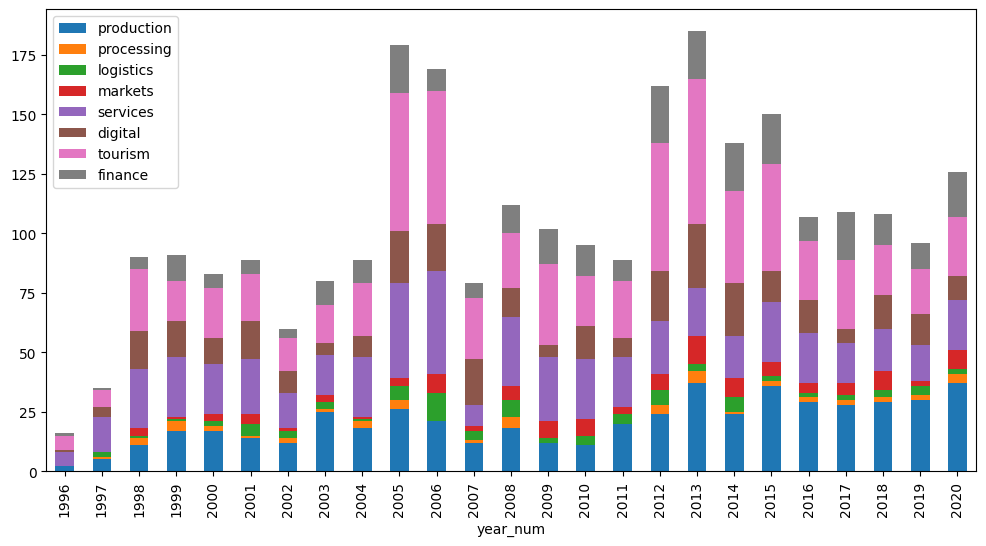

In [15]:
year_series = pd.to_numeric(df.get("year", pd.Series(dtype="object")), errors="coerce")
df_year = df.assign(year_num=year_series).dropna(subset=["year_num"])

text_year = (
    df_year.get("title", "").fillna("").astype(str)
    + " "
    + df_year.get("snippet_clean", "").fillna("").astype(str)
 ).str.lower()

vc_year_counts = {}
for stage, terms in value_chain.items():
    hits = text_year.str.contains("|".join(map(re.escape, terms)), regex=True)
    vc_year_counts[stage] = (
        df_year.assign(hit=hits)
        .groupby("year_num")["hit"].sum()
    )

vc_year_df = pd.DataFrame(vc_year_counts).fillna(0).sort_index()
vc_year_df = vc_year_df.astype(int)

vc_year_df.plot(kind="bar", stacked=True, figsize=(12, 6))

vc_year_df

## 4) Apoios para desenvolvimento vs desenvolvimento real
Contrastamos a linguagem de financiamento e incentivos com a linguagem de impacto, assim como das narrativas de sustentabilidade.

In [16]:
inputs_terms = ["financiamento", "incentivos", "apoio", "subsidio", "subsídio"]
outcome_terms = ["emprego", "produtividade", "rendimento", "crescimento", "qualidade de vida"]
inputs_hits = text.str.contains("|".join(map(re.escape, inputs_terms)), regex=True).sum()
outcome_hits = text.str.contains("|".join(map(re.escape, outcome_terms)), regex=True).sum()
inputs_hits, outcome_hits

(np.int64(536), np.int64(283))

In [17]:
sustain_terms = ["sustentavel", "sustentável", "biodiversidade", "energia", "renovavel", "renovável", "agua", "água"]
sustain_hits = text.str.contains("|".join(map(re.escape, sustain_terms)), regex=True).sum()
sustain_hits

np.int64(670)

In [18]:
from urllib.parse import urlparse
df["domain"] = df.get("original_url", "").fillna("").map(lambda u: urlparse(u).netloc.lower())
places_terms = ["beira", "tras-os-montes", "alentejo", "algarve", "interior"]
places_hits = text.str.contains("|".join(map(re.escape, places_terms)), regex=True).sum()
places_hits

np.int64(468)

In [19]:
media_domains = ["publico.pt", "expresso.pt", "dn.pt", "lusa.pt", "jnoticias.pt"]
media_mask = df["domain"].str.contains("|".join(map(re.escape, media_domains)), na=False)
media_df = df[media_mask].copy()
inst_df = df[~media_mask].copy()
len(media_df), len(inst_df)

(70, 6482)